# Spectral Bridge — Recovering Lost Audio with an Attentive Neural Process

> *In the winter of 1974, The New Yardbirds retreated to Headley Grange to record their final album,
> codenamed **Spectral Graffiti**. The tapes were never released. Decades in a damp London basement
> caused catastrophic Sticky Shed Syndrome — the magnetic oxide physically separated from the reels,
> leaving microscopic gaps of **absolute signal loss** in the recordings.*

This notebook is my solution for the **Spectral Bridge** challenge: a few-shot signal in-painting
problem where we must reconstruct the missing waveform fragments using only the surviving
context points from each clip.


### The approach: Attentive Neural Process (ANP)

A neural process is a meta-learning model designed exactly for this kind of task — it takes
a set of observed points as input (the "context") and predicts values at arbitrary query
locations (the "targets") in a **single forward pass** (amortized inference).

I chose the Attentive variant because cross-attention lets each target point selectively
focus on the most relevant context points rather than relying on a single pooled summary.
Combined with Fourier positional encoding to capture the harmonic structure of audio signals,
this gives us a model that can reconstruct diverse waveforms from sparse observations.

### Pipeline overview
1. Load and explore the recovered voltage readings
2. Build a sample-wise dataset with stochastic augmentation
3. Define the ANP architecture (Fourier encoding + cross-attention)
4. Train with masked MSE loss and early stopping
5. Validate with qualitative waveform plots
6. Run inference and export `submission.csv`


In [22]:
# Uncomment and run once if you're on a fresh machine
# !pip install torch pandas numpy matplotlib tqdm scikit-learn


In [23]:
import math
import os
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


## 1) Configuration

All hyperparameters in one place. I used a dataclass to keep things organised —
if I want to try a different hidden size or learning rate during an ablation,
there's exactly one spot to change.

A few notes on the choices:
- **80 epochs** with **patience 10** — the cosine LR schedule needs room to decay;
  early stopping catches it if convergence happens sooner.
- **Fourier frequencies = 32** — the signals are sampled at 1 kHz over 100 ms windows,
  so we need enough spectral resolution to represent harmonics up to ~500 Hz (Nyquist).
- **Augmentation probability = 0.70** — during training, 70% of the time we randomly
  re-decide which points are context vs target. This is critical because it stops the
  model from overfitting to the specific context split in the CSV and teaches it to
  work with any observation density.


In [24]:
@dataclass
class Config:
    # ── File paths ──────────────────────────────────────────────────
    train_csv: Path = Path("train.csv")
    test_csv_candidates: Tuple[str, ...] = (
        "test.csv", "Test.csv", "round1_test.csv",         # same directory
        "test_data/test.csv", "test_data/Test.csv",         # test_data/ subdirectory
        "test_data/round1_test.csv",
    )
    submission_path: Path = Path("submission.csv")
    checkpoint_path: Path = Path("best_anp.pt")

    # ── Reproducibility ─────────────────────────────────────────────
    seed: int = 42

    # ── Training loop ───────────────────────────────────────────────
    batch_size: int = 128 if torch.cuda.is_available() else 64      # GPU can handle larger batches
    num_workers: int = 4 if torch.cuda.is_available() else 0        # parallel data loading on GPU machines
    epochs: int = 12            # cosine LR needs room; early stopping handles the rest
    patience: int = 10          # halt if val MSE stagnates for this many epochs
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4  # L2 regularisation inside AdamW

    # ── Model architecture ──────────────────────────────────────────
    num_frequencies: int = 32   # Fourier frequency bands for time encoding
    d_hidden: int = 128         # width of encoder/decoder MLPs
    encoder_layers: int = 4     # depth of the context encoder
    decoder_layers: int = 4     # depth of the target decoder
    attention_heads: int = 4    # heads in multi-head cross-attention
    dropout: float = 0.1        # regularisation dropout during training

    # ── Validation split ────────────────────────────────────────────
    val_size: float = 0.10              # 10% of samples held out
    time_norm_divisor: float = 100.0    # each clip is 100 ms, so this maps time to [0, 1]

    # ── Data augmentation ───────────────────────────────────────────
    # We randomly reassign context vs target roles during training.
    # This is essential — without it the model memorises the fixed
    # split from the CSV and generalises poorly to the test set.
    augment_prob: float = 0.70                                      # full repartition probability
    random_context_ratio_range: Tuple[float, float] = (0.35, 0.85)  # how much context to keep

    flip_prob: float = 0.10                                         # mild per-point role flip


CFG = Config()
print(f"Config: batch_size={CFG.batch_size}, num_workers={CFG.num_workers}, device={'CUDA' if torch.cuda.is_available() else 'CPU/MPS'}")


Config: batch_size=64, num_workers=0, device=CPU/MPS


In [25]:
import os
import pathlib
import torch.serialization

def clean_config_for_checkpoint(cfg):
    # Convert all pathlib.Path/PosixPath to str for checkpoint safety
    cfg_dict = dict(cfg.__dict__)
    for k, v in cfg_dict.items():
        if isinstance(v, pathlib.Path):
            cfg_dict[k] = str(v)
    return cfg_dict

def load_checkpoint_if_exists(model, optimizer, scheduler, checkpoint_path, device):
    """
    Loads model, optimizer, and scheduler state if checkpoint exists. Returns start_epoch and best_val_mse.
    Handles pathlib.PosixPath for PyTorch >=2.6.
    """
    if os.path.exists(checkpoint_path):
        print(f"Resuming from checkpoint: {checkpoint_path}")
        torch.serialization.add_safe_globals([pathlib.PosixPath])
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint["model_state_dict"])
        if optimizer is not None and "optimizer_state_dict" in checkpoint:
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        if scheduler is not None and "scheduler_state_dict" in checkpoint:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = checkpoint.get("epoch", 0) + 1
        best_val_mse = checkpoint.get("best_val_mse", float("inf"))
        print(f"Resumed at epoch {start_epoch}, best val MSE = {best_val_mse:.6f}")
        return start_epoch, best_val_mse
    else:
        return 1, float("inf")


## 2) Utilities — Seeding, Device Selection, Loss Function

The masked MSE is the competition metric. Since samples have different lengths and
we pad them to form batches, we need to ignore padded positions when computing the loss.
I split this into a `_components` helper (returns sum-of-squares + count separately) so
we can aggregate correctly across batches of different sizes.


In [26]:
def set_seed(seed: int) -> None:
    """Pin every source of randomness so results are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    """Auto-detect the best available hardware: CUDA GPU > Apple Silicon > CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def masked_mse_components(
    y_pred: torch.Tensor, y_true: torch.Tensor, mask: torch.Tensor
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Return (sum_of_squared_errors, count_of_valid_points).

    We keep them separate so we can accumulate across variable-size batches
    and divide at the end — avoids the classic "average of averages" bias.
    """
    diff = (y_pred.squeeze(-1) - y_true.squeeze(-1)) ** 2
    mask_f = mask.float()
    return (diff * mask_f).sum(), mask_f.sum().clamp_min(1.0)


def masked_mse(y_pred: torch.Tensor, y_true: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """MSE computed only over real target positions (padding is ignored)."""
    sse, n = masked_mse_components(y_pred, y_true, mask)
    return sse / n


## 3) Data Loading + Exploratory Analysis

The training data is a single CSV (`train.csv`) with ~8 million rows across 80,000 samples.
Each sample is an independent 100 ms audio clip sampled at 1 kHz, giving roughly 100 time
points per clip.

**Columns:**
| Column | Type | Description |
|---|---|---|
| `Sample_ID` | int | Unique identifier for each clip |
| `Time_ms` | float | Timestamp in milliseconds |
| `Is_Context` | 0 or 1 | 1 = surviving fragment, 0 = missing (to predict) |
| `Value` | float | Voltage reading (only meaningful where `Is_Context=1` for test data) |

After loading, I print summary statistics and plot a few random samples so we can
visually confirm what the waveforms look like before feeding them to the model.


In [27]:
def load_dataframe(csv_path: Path, is_train: bool = True) -> pd.DataFrame:
    """
    Load the competition CSV with memory-efficient dtypes.
    The file is ~140 MB so using int32/float32 instead of int64/float64 helps.
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path.resolve()}")

    dtype_map = {
        "Sample_ID": np.int32,
        "Time_ms":   np.float32,
        "Is_Context": np.int8,
    }
    if is_train:
        dtype_map["Value"] = np.float32

    df = pd.read_csv(csv_path, dtype=dtype_map, low_memory=False)

    # Quick sanity check on columns
    required = {"Sample_ID", "Time_ms", "Is_Context"}
    if is_train:
        required.add("Value")
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path.name} is missing columns: {sorted(missing)}")

    # Sort chronologically within each sample
    df = df.sort_values(["Sample_ID", "Time_ms"], kind="mergesort").reset_index(drop=True)
    return df


def eda_report(df: pd.DataFrame, title: str = "Train Data") -> None:
    """Print a concise summary of the dataset."""
    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    print(f"Shape:              {df.shape[0]:,} rows x {df.shape[1]} cols")
    print(f"Unique samples:     {df['Sample_ID'].nunique():,}")
    print(f"Null values:        {df.isnull().sum().sum()}")
    print(f"\nColumn dtypes:")
    for col in df.columns:
        print(f"  {col:15s}  {str(df[col].dtype):10s}  range=[{df[col].min():.4f}, {df[col].max():.4f}]")

    # Per-sample breakdown
    per_sample = (
        df.groupby("Sample_ID")["Is_Context"]
        .agg(
            context_pts=lambda s: int((s == 1).sum()),
            target_pts=lambda s: int((s == 0).sum()),
        )
    )
    print(f"\nPoints per sample (averaged over {len(per_sample):,} samples):")
    print(f"  Context:  {per_sample['context_pts'].mean():.1f}  (what we can see)")
    print(f"  Target:   {per_sample['target_pts'].mean():.1f}  (what we must predict)")
    print(f"  Total:    {(per_sample['context_pts'] + per_sample['target_pts']).mean():.1f}")


def plot_random_samples(df: pd.DataFrame, n_samples: int = 5, seed: int = 42) -> None:
    """
    Plot a handful of random clips to get a feel for the data.
    Blue = context (surviving fragments), Red = target (gaps to fill).
    """
    unique_ids = df["Sample_ID"].unique()
    n_samples  = min(n_samples, len(unique_ids))
    rng        = np.random.default_rng(seed)
    chosen_ids = rng.choice(unique_ids, size=n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 1, figsize=(12, 3.0 * n_samples), squeeze=False)
    axes = axes.ravel()

    for ax, sid in zip(axes, chosen_ids):
        sdf = df[df["Sample_ID"] == sid].sort_values("Time_ms")

        # Faint line showing the full waveform shape (for train data only)
        if "Value" in sdf.columns:
            ax.plot(sdf["Time_ms"], sdf["Value"], color="gray", alpha=0.3, lw=1, label="Full waveform")

        ctx = sdf[sdf["Is_Context"] == 1]
        tgt = sdf[sdf["Is_Context"] == 0]
        ax.scatter(ctx["Time_ms"], ctx["Value"], s=14, color="royalblue", zorder=3, label="Context (visible)")
        ax.scatter(tgt["Time_ms"], tgt["Value"], s=18, color="crimson",   zorder=3, label="Target (missing)")
        ax.set_title(f"Sample {int(sid)}", fontsize=10)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Voltage")
        ax.grid(alpha=0.15)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=9)
    fig.suptitle("Random training samples — blue is what we see, red is what we predict", fontsize=11, y=1.01)
    fig.tight_layout()
    plt.show()


## 4) Dataset Pipeline — Records, Augmentation, and Padding

### Pre-processing

We convert each `Sample_ID` group into a compact dict of numpy arrays ("record") once at startup.
This avoids slow DataFrame indexing inside `__getitem__` during training.

### The critical trick: stochastic context/target reshuffling

In the competition CSV, each sample has a fixed context/target split. If we train on that split
alone, the model memorises it. At test time, the split is different and performance tanks.

The fix: during training, we randomly reassign which points are "context" and "target" for each
sample on every pass. This forces the model to genuinely learn the mapping from *any* set of
observations to *any* set of predictions — which is exactly what we need for generalisation.

Two strategies are mixed:
- **Strategy A (70%)**: completely re-partition points with a random context fraction in [0.35, 0.85]
- **Strategy B (30%)**: mildly perturb the original split by randomly flipping individual points


In [28]:
def build_sample_records(
    df: pd.DataFrame, time_norm_divisor: float
) -> List[Dict[str, np.ndarray]]:
    """
    Convert the raw DataFrame into a list of per-sample dicts.

    Each dict holds numpy arrays for one clip: normalised time, raw time,
    observed values, and the boolean context mask. This is done once so
    the DataLoader doesn't have to slice a DataFrame on every batch.
    """
    records: List[Dict[str, np.ndarray]] = []

    grouped = df.groupby("Sample_ID", sort=True, observed=True)
    for sample_id, sdf in tqdm(grouped, total=df["Sample_ID"].nunique(), desc="Building sample records"):
        time_raw   = sdf["Time_ms"].to_numpy(dtype=np.float32, copy=True)
        x_normed   = time_raw / np.float32(time_norm_divisor)   # map to ~[0, 1]
        is_context = sdf["Is_Context"].to_numpy(dtype=np.int8, copy=True) == 1

        # For test data without a Value column, fill with NaN — the model
        # only reads context values, so NaN in target rows is fine
        if "Value" in sdf.columns:
            y = sdf["Value"].to_numpy(dtype=np.float32, copy=True)
        else:
            y = np.full_like(x_normed, np.nan, dtype=np.float32)

        records.append({
            "sample_id":  np.int32(sample_id),
            "x":          x_normed,
            "time_raw":   time_raw,
            "y":          y,
            "is_context": is_context,
        })

    return records


# ─────────────────────────────────────────────────────────────────
# Training dataset with on-the-fly augmentation
# ─────────────────────────────────────────────────────────────────
class SpectralBridgeDataset(Dataset):
    """
    Wraps pre-processed sample records for training or validation.

    During training, the context/target partition is randomly reshuffled on every
    access — this is the main data augmentation and is essential for generalisation.
    During validation, the original partition from the CSV is preserved.

    Returns (x_context, y_context, x_target, y_target), each shaped [N, 1].
    """

    def __init__(self, records: Sequence[Dict[str, np.ndarray]], train_mode: bool, cfg: Config):
        self.records    = records
        self.train_mode = train_mode
        self.cfg        = cfg
        self.rng        = np.random.default_rng(cfg.seed)

    def __len__(self):
        return len(self.records)

    @staticmethod
    def _ensure_non_empty(mask: np.ndarray) -> np.ndarray:
        """Make sure there's at least one context and one target point."""
        if mask.sum() == 0:
            mask[0] = True
        if mask.sum() == len(mask):
            mask[-1] = False
        return mask

    def _augment_mask(self, base_mask: np.ndarray) -> np.ndarray:
        """
        Randomly reassign which points are context vs target.

        70% of the time: full random repartition with context ratio in [0.35, 0.85]
        30% of the time: mild perturbation — flip each point's role with 10% probability
        """
        mask = base_mask.copy()
        n    = len(mask)

        if self.rng.random() < self.cfg.augment_prob:
            # Full random repartition
            lo, hi    = self.cfg.random_context_ratio_range
            ratio     = float(self.rng.uniform(lo, hi))
            k_context = int(np.clip(round(ratio * n), 1, n - 1))
            perm      = self.rng.permutation(n)
            mask[:]   = False
            mask[perm[:k_context]] = True
        else:
            # Mild perturbation around the original split
            flips = self.rng.random(n) < self.cfg.flip_prob
            mask  = np.logical_xor(mask, flips)

        return self._ensure_non_empty(mask)

    def __getitem__(self, idx):
        rec = self.records[idx]
        x, y, is_ctx = rec["x"], rec["y"], rec["is_context"]

        if self.train_mode:
            is_ctx = self._augment_mask(is_ctx)
        else:
            is_ctx = self._ensure_non_empty(is_ctx.copy())

        ctx_idx = np.where(is_ctx)[0]
        tgt_idx = np.where(~is_ctx)[0]

        return (
            torch.from_numpy(x[ctx_idx]).unsqueeze(-1),    # x_context [Nc, 1]
            torch.from_numpy(y[ctx_idx]).unsqueeze(-1),    # y_context [Nc, 1]
            torch.from_numpy(x[tgt_idx]).unsqueeze(-1),    # x_target  [Nt, 1]
            torch.from_numpy(y[tgt_idx]).unsqueeze(-1),    # y_target  [Nt, 1]
        )


# ─────────────────────────────────────────────────────────────────
# Collate: pad variable-length samples to form a batch
# ─────────────────────────────────────────────────────────────────
def collate_train_val(batch):
    """
    Pad variable-length context/target sequences to the batch maximum.

    Each sample can have a different number of context and target points,
    so shorter sequences are zero-padded. We return boolean masks so the
    model and loss function know which positions are real.
    """
    bsz     = len(batch)
    max_ctx = max(b[0].shape[0] for b in batch)
    max_tgt = max(b[2].shape[0] for b in batch)

    x_ctx  = torch.zeros(bsz, max_ctx, 1)
    y_ctx  = torch.zeros(bsz, max_ctx, 1)
    x_tgt  = torch.zeros(bsz, max_tgt, 1)
    y_tgt  = torch.zeros(bsz, max_tgt, 1)
    m_ctx  = torch.zeros(bsz, max_ctx, dtype=torch.bool)
    m_tgt  = torch.zeros(bsz, max_tgt, dtype=torch.bool)

    for i, (xc, yc, xt, yt) in enumerate(batch):
        nc, nt = xc.shape[0], xt.shape[0]
        x_ctx[i, :nc] = xc;  y_ctx[i, :nc] = yc;  m_ctx[i, :nc] = True
        x_tgt[i, :nt] = xt;  y_tgt[i, :nt] = yt;  m_tgt[i, :nt] = True

    return {
        "x_context": x_ctx,  "y_context": y_ctx,
        "x_target":  x_tgt,  "y_target":  y_tgt,
        "context_mask": m_ctx, "target_mask": m_tgt,
    }


# ─────────────────────────────────────────────────────────────────
# Inference dataset (no augmentation, carries sample IDs)
# ─────────────────────────────────────────────────────────────────
class InferenceDataset(Dataset):
    """Thin wrapper for inference — no augmentation, just the original split."""

    def __init__(self, records: Sequence[Dict[str, np.ndarray]]):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        is_ctx = rec["is_context"].copy()

        # Guard against edge cases
        if is_ctx.sum() == 0:    is_ctx[0]  = True
        if is_ctx.all():         is_ctx[-1] = False

        ctx_idx = np.where(is_ctx)[0]
        tgt_idx = np.where(~is_ctx)[0]

        return (
            torch.from_numpy(rec["x"][ctx_idx]).unsqueeze(-1),
            torch.from_numpy(rec["y"][ctx_idx]).unsqueeze(-1),
            torch.from_numpy(rec["x"][tgt_idx]).unsqueeze(-1),
            int(rec["sample_id"]),
            rec["time_raw"][tgt_idx],               # raw timestamps for submission file
        )


def collate_inference(batch):
    """Collate for inference: same padding logic, but also passes through sample IDs and raw timestamps."""
    bsz     = len(batch)
    max_ctx = max(b[0].shape[0] for b in batch)
    max_tgt = max(b[2].shape[0] for b in batch)

    x_ctx  = torch.zeros(bsz, max_ctx, 1)
    y_ctx  = torch.zeros(bsz, max_ctx, 1)
    x_tgt  = torch.zeros(bsz, max_tgt, 1)
    m_ctx  = torch.zeros(bsz, max_ctx, dtype=torch.bool)
    m_tgt  = torch.zeros(bsz, max_tgt, dtype=torch.bool)
    sids, time_raws = [], []

    for i, (xc, yc, xt, sid, traw) in enumerate(batch):
        nc, nt = xc.shape[0], xt.shape[0]
        x_ctx[i, :nc] = xc;  y_ctx[i, :nc] = yc;  m_ctx[i, :nc] = True
        x_tgt[i, :nt] = xt;                        m_tgt[i, :nt] = True
        sids.append(sid)
        time_raws.append(traw)

    return {
        "x_context": x_ctx,  "y_context": y_ctx,  "x_target": x_tgt,
        "context_mask": m_ctx, "target_mask": m_tgt,
        "sample_ids": sids, "time_targets_raw": time_raws,
    }


## 5) Model — Fourier-Encoded Attentive Neural Process

### Why this architecture fits the problem

The Spectral Graffiti tapes contain signals with rich harmonic structure — bass vibrations,
cymbal transients, synth drones. Each instrument has a different spectral signature, and
the model has to infer it from whatever context points are available.

**Fourier time encoding** solves the "how to represent time" problem. A raw scalar timestamp
`t` is expanded into `[t, sin(2π·f₁·t), cos(2π·f₁·t), ..., sin(2π·f₃₂·t), cos(2π·f₃₂·t)]`.
This gives the model 65-dimensional features that naturally capture periodicity at multiple
frequency scales — exactly what audio signals need.

**Cross-attention** is the key to making this an in-context learner. For each target timestamp,
the model computes attention weights over all context points, effectively asking:
*"Which observed fragments are most relevant for predicting this particular gap?"*
A target in a rising waveform segment will attend to nearby context points that show the
same rising trend, while ignoring distant fragments from a different part of the clip.

**Single forward pass**: the whole prediction happens in one `model(context, targets)` call —
no iterative fitting, no per-sample optimisation. This satisfies the amortized inference
constraint of the competition.

```
  Context (time, value) ──> Fourier Enc ──> MLP Encoder ──> K, V
                                                              │
  Target timestamps ─────> Fourier Enc ─────────────────> Q ──┤
                                                              │
                                                    Cross-Attention
                                                              │
                                            [target_enc, attn_output]
                                                              │
                                                        MLP Decoder ──> predicted values
```


In [29]:
class FourierTimeEncoding(nn.Module):
    """
    Project a scalar timestamp into a high-dimensional sinusoidal feature vector.

    This is the same idea as positional encoding in Transformers and NeRF:
    the sin/cos features let the network easily represent periodic patterns,
    which is exactly what audio waveforms are.

    Output dim = 1 (raw time) + 2 * num_frequencies (sin + cos per band).
    """

    def __init__(self, num_frequencies: int = 32, max_frequency: float = 64.0):
        super().__init__()
        self.num_frequencies = num_frequencies
        freqs = torch.linspace(1.0, max_frequency, steps=num_frequencies)
        self.register_buffer("freqs", freqs)

    @property
    def out_dim(self) -> int:
        return 1 + 2 * self.num_frequencies     # 1 + 64 = 65 by default

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, N, 1] — normalised time values in roughly [0, 1]
        phases = 2.0 * math.pi * x * self.freqs.view(1, 1, -1)     # [B, N, F]
        return torch.cat([x, torch.sin(phases), torch.cos(phases)], dim=-1)


def build_mlp(in_dim: int, hidden: int, out_dim: int, depth: int, drop: float) -> nn.Sequential:
    """Stack of Linear -> ReLU -> LayerNorm -> Dropout, ending with a bare Linear."""
    layers: list = []
    d = in_dim
    for _ in range(depth - 1):
        layers += [nn.Linear(d, hidden), nn.ReLU(), nn.LayerNorm(hidden), nn.Dropout(drop)]
        d = hidden
    layers.append(nn.Linear(d, out_dim))
    return nn.Sequential(*layers)


class AttentiveNeuralProcess(nn.Module):
    """
    Attentive Neural Process (ANP) for few-shot signal regression.

    Forward pass:
      1. Fourier-encode all timestamps (context and target)
      2. Encode each context point (time_features + observed_value) -> latent embedding
      3. Cross-attend: each target point queries the context embeddings
      4. Decode (target_time_features + attention_output) -> predicted value
    """

    def __init__(self, num_frequencies=32, d_hidden=128, encoder_layers=4,
                 decoder_layers=4, attention_heads=4, dropout=0.1):
        super().__init__()
        self.time_enc = FourierTimeEncoding(num_frequencies)
        d_t = self.time_enc.out_dim                 # 65

        # Context encoder: maps (fourier_time, value) -> hidden embedding
        self.encoder = build_mlp(d_t + 1, d_hidden, d_hidden, encoder_layers, dropout)

        # Cross-attention: targets query the context embeddings
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_hidden, num_heads=attention_heads,
            dropout=dropout, batch_first=True,
        )
        self.q_proj = nn.Linear(d_t, d_hidden)      # target time -> query
        self.k_proj = nn.Linear(d_t, d_hidden)      # context time -> key

        # Decoder: maps (fourier_time, attended_context) -> scalar prediction
        self.decoder = build_mlp(d_t + d_hidden, d_hidden, 1, decoder_layers, dropout)

    def forward(self, x_context, y_context, x_target, context_mask, target_mask=None):
        # ── Encode timestamps ────────────────────────────────────────
        enc_xc = self.time_enc(x_context)           # [B, Nc, 65]
        enc_xt = self.time_enc(x_target)            # [B, Nt, 65]

        # Zero out padded context so it doesn't leak into the encoder
        cm = context_mask.unsqueeze(-1).float()
        enc_xc    = enc_xc * cm
        y_context = y_context * cm

        # ── Context encoding ─────────────────────────────────────────
        h = self.encoder(torch.cat([enc_xc, y_context], dim=-1))    # [B, Nc, H]
        h = h * cm                                  # re-mask after the MLP

        # ── Cross-attention ──────────────────────────────────────────
        q = self.q_proj(enc_xt)                     # target queries
        k = self.k_proj(enc_xc)                     # context keys
        attn_out, _ = self.cross_attn(
            query=q, key=k, value=h,
            key_padding_mask=~context_mask,          # True = ignore
            need_weights=False,
        )

        # ── Mask target padding if present ───────────────────────────
        if target_mask is not None:
            tm = target_mask.unsqueeze(-1).float()
            attn_out = attn_out * tm
            enc_xt   = enc_xt * tm

        # ── Decode to predictions ────────────────────────────────────
        return self.decoder(torch.cat([enc_xt, attn_out], dim=-1))  # [B, Nt, 1]


## 6) Training and Validation

**Loss**: Masked MSE on target points only — padded positions are excluded.

**Optimiser**: AdamW with weight decay 1e-4. AdamW decouples the weight decay from the
gradient update, which tends to work better than vanilla Adam for models with LayerNorm.

**LR schedule**: Cosine annealing over the full 80 epochs. The learning rate starts at 1e-3
and smoothly decays toward zero. Early stopping (patience 10) prevents wasted compute if the
model converges early.

**Gradient clipping**: max norm 1.0 — attention layers can produce large gradients, especially
early in training. Clipping keeps things stable.

We also compute a **naive baseline** before training: predict the mean of the context values
for every target point. If our trained model can't beat this, something is fundamentally wrong.


In [30]:
def run_one_epoch(model, loader, optimizer, device, train):
    """One pass through the data. Returns global MSE across all valid target points."""
    model.train() if train else model.eval()
    total_sse = total_n = 0.0

    pbar = tqdm(loader, desc="Train" if train else "Val", leave=False)
    for batch in pbar:
        xc = batch["x_context"].to(device)
        yc = batch["y_context"].to(device)
        xt = batch["x_target"].to(device)
        yt = batch["y_target"].to(device)
        cm = batch["context_mask"].to(device)
        tm = batch["target_mask"].to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            pred = model(xc, yc, xt, cm, tm)
            loss = masked_mse(pred, yt, tm)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        sse, n = masked_mse_components(pred.detach(), yt, tm)
        total_sse += sse.item()
        total_n   += n.item()
        pbar.set_postfix(mse=f"{total_sse / max(total_n, 1):.6f}")

    return total_sse / max(total_n, 1)


@torch.no_grad()
def baseline_context_mean(loader, device):
    """Naive baseline: predict each sample's context-mean as the value for every target point."""
    total_sse = total_n = 0.0
    for batch in tqdm(loader, desc="Baseline", leave=False):
        yc = batch["y_context"].to(device)
        yt = batch["y_target"].to(device)
        cm = batch["context_mask"].to(device)
        tm = batch["target_mask"].to(device)

        # Per-sample mean of context values
        cm_f = cm.float()
        mean = (yc.squeeze(-1) * cm_f).sum(1, keepdim=True) / cm_f.sum(1, keepdim=True).clamp_min(1)
        pred = mean.unsqueeze(-1).expand_as(yt)

        sse, n = masked_mse_components(pred, yt, tm)
        total_sse += sse.item()
        total_n   += n.item()
    return total_sse / max(total_n, 1)


def train_model(model, train_loader, val_loader, cfg, device):
    """
    Train the ANP with AdamW + cosine LR + early stopping.
    Saves the best checkpoint to disk whenever val MSE improves.
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    history    = {"train_mse": [], "val_mse": []}
    best_val   = float("inf")
    bad_epochs = 0

    for epoch in range(1, cfg.epochs + 1):
        tr_mse  = run_one_epoch(model, train_loader, optimizer, device, train=True)
        val_mse = run_one_epoch(model, val_loader, None, device, train=False)
        scheduler.step()

        history["train_mse"].append(tr_mse)
        history["val_mse"].append(val_mse)

        lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch:03d}/{cfg.epochs}  |  Train MSE {tr_mse:.6f}  |  Val MSE {val_mse:.6f}  |  LR {lr:.2e}")

        if val_mse < best_val:
            best_val, bad_epochs = val_mse, 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "config":           cfg.__dict__,
                "best_val_mse":     best_val,
                "epoch":            epoch,
            }, cfg.checkpoint_path)
            print(f"  >> saved checkpoint (val MSE = {best_val:.6f})")
        else:
            bad_epochs += 1
            if bad_epochs >= cfg.patience:
                print(f"Early stopping at epoch {epoch} — no improvement for {cfg.patience} epochs.")
                break

    return history


In [31]:
def train_model(model, train_loader, val_loader, cfg, device):
    """
    Train the ANP with AdamW + cosine LR + early stopping.
    Saves the best checkpoint to disk whenever val MSE improves.
    Supports resuming from checkpoint.
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    # Resume if checkpoint exists
    start_epoch, best_val = load_checkpoint_if_exists(model, optimizer, scheduler, cfg.checkpoint_path, device)
    history    = {"train_mse": [], "val_mse": []}
    bad_epochs = 0

    for epoch in range(start_epoch, cfg.epochs + 1):
        tr_mse  = run_one_epoch(model, train_loader, optimizer, device, train=True)
        val_mse = run_one_epoch(model, val_loader, None, device, train=False)
        scheduler.step()

        history["train_mse"].append(tr_mse)
        history["val_mse"].append(val_mse)

        lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch:03d}/{cfg.epochs}  |  Train MSE {tr_mse:.6f}  |  Val MSE {val_mse:.6f}  |  LR {lr:.2e}")

        if val_mse < best_val:
            best_val, bad_epochs = val_mse, 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "config":           clean_config_for_checkpoint(cfg),
                "best_val_mse":     best_val,
                "epoch":            epoch,
            }, cfg.checkpoint_path)
            print(f"  >> saved checkpoint (val MSE = {best_val:.6f})")
        else:
            bad_epochs += 1
            if bad_epochs >= cfg.patience:
                print(f"Early stopping at epoch {epoch} — no improvement for {cfg.patience} epochs.")
                break

    return history


## 7) Validation Visualisation

Numbers only tell part of the story. Plotting the model's predictions on held-out clips
lets us eyeball whether it's capturing the right waveform shape — a low MSE could still
mean the model is smoothing out important transients, and plots reveal that immediately.

For each sample we show:
- **Blue dots**: context points (what the model sees)
- **Red dots**: true target values (ground truth)
- **Green line**: model predictions (what we're evaluating)


In [32]:
@torch.no_grad()
def predict_single(model, record, device):
    """Run the model on one sample for visualisation. Returns arrays for plotting."""
    is_ctx = record["is_context"].copy()
    if is_ctx.sum() == 0:    is_ctx[0]  = True
    if is_ctx.all():         is_ctx[-1] = False

    ci = np.where(is_ctx)[0]
    ti = np.where(~is_ctx)[0]

    xc = torch.from_numpy(record["x"][ci]).float()[None, :, None].to(device)
    yc = torch.from_numpy(record["y"][ci]).float()[None, :, None].to(device)
    xt = torch.from_numpy(record["x"][ti]).float()[None, :, None].to(device)
    cm = torch.ones(1, len(ci), dtype=torch.bool, device=device)
    tm = torch.ones(1, len(ti), dtype=torch.bool, device=device)

    pred = model(xc, yc, xt, cm, tm).squeeze(0).squeeze(-1).cpu().numpy()

    return {
        "sample_id":     int(record["sample_id"]),
        "time_context":  record["time_raw"][ci],
        "y_context":     record["y"][ci],
        "time_target":   record["time_raw"][ti],
        "y_true":        record["y"][ti],
        "y_pred":        pred,
    }


def plot_val_predictions(model, val_records, device, n=10, seed=42):
    """Plot predicted vs true waveforms for random validation samples."""
    rng = np.random.default_rng(seed)
    n   = min(n, len(val_records))
    idx = rng.choice(len(val_records), size=n, replace=False)

    fig, axes = plt.subplots(n, 1, figsize=(13, 3.0 * n), squeeze=False)

    for ax, i in zip(axes.ravel(), idx):
        out   = predict_single(model, val_records[i], device)
        order = np.argsort(out["time_target"])

        ax.scatter(out["time_context"], out["y_context"],        s=14, c="royalblue", label="Context",    zorder=3)
        ax.scatter(out["time_target"],  out["y_true"],           s=18, c="crimson",   label="True target", zorder=3, alpha=0.7)
        ax.plot(   out["time_target"][order], out["y_pred"][order], c="green", lw=2,  label="Predicted",   zorder=2)
        ax.scatter(out["time_target"][order], out["y_pred"][order], s=12, c="green",  zorder=2)
        ax.set_title(f"Sample {out['sample_id']}", fontsize=10)
        ax.set_xlabel("Time (ms)");  ax.set_ylabel("Voltage")
        ax.grid(alpha=0.15)

    fig.legend(*axes.ravel()[0].get_legend_handles_labels(), loc="upper right", fontsize=9)
    fig.suptitle("Validation predictions — green should track red", fontsize=11, y=1.01)
    fig.tight_layout()
    plt.show()


## 8) Inference + Submission

The competition expects a CSV with three columns: `Sample_ID`, `Time_ms`, `Predicted_Value`.
We only need to predict rows where `Is_Context == 0` (the missing gaps), though submitting
the full sequence is also accepted — context predictions are ignored during scoring.

If no test file is found (test data is released at the event), we run inference on the
training set as a pipeline sanity check.


In [33]:
def find_test_csv(candidates):
    """Try a list of common file paths until we find the test CSV."""
    for c in candidates:
        p = Path(c)
        if p.exists():
            return p
    return None


@torch.no_grad()
def run_inference(model, records, batch_size, num_workers, device):
    """Batch inference over all records. Returns a submission-ready DataFrame."""
    loader = DataLoader(
        InferenceDataset(records),
        batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=(device.type == "cuda"),
        collate_fn=collate_inference,
    )

    rows_sid, rows_time, rows_pred = [], [], []

    model.eval()
    for batch in tqdm(loader, desc="Inference"):
        xc = batch["x_context"].to(device)
        yc = batch["y_context"].to(device)
        xt = batch["x_target"].to(device)
        cm = batch["context_mask"].to(device)
        tm = batch["target_mask"].to(device)

        pred = model(xc, yc, xt, cm, tm).squeeze(-1).cpu().numpy()       # [B, Nt]
        tm_np = batch["target_mask"].numpy()

        for i, sid in enumerate(batch["sample_ids"]):
            valid = int(tm_np[i].sum())
            rows_sid.extend([sid] * valid)
            rows_time.extend(batch["time_targets_raw"][i][:valid].tolist())
            rows_pred.extend(pred[i, :valid].tolist())

    return (
        pd.DataFrame({
            "Sample_ID":       np.array(rows_sid,  dtype=np.int32),
            "Time_ms":         np.array(rows_time, dtype=np.float32),
            "Predicted_Value": np.array(rows_pred, dtype=np.float32),
        })
        .sort_values(["Sample_ID", "Time_ms"], kind="mergesort")
        .reset_index(drop=True)
    )


## 9) Run Everything

One cell to run the full pipeline end-to-end: load data, train, evaluate, infer, and write the submission file.

If you already have a trained checkpoint (`best_anp.pt`), you can skip the training step by
commenting out the `history = train_model(...)` block and jumping straight to the checkpoint
reload + inference section below.


Device: mps

  Train Data
Shape:              8,000,000 rows x 4 cols
Unique samples:     80,000
Null values:        0

Column dtypes:
  Sample_ID        int32       range=[10000.0000, 89999.0000]
  Time_ms          float32     range=[1.0000, 100.0000]
  Is_Context       int8        range=[0.0000, 1.0000]
  Value            float32     range=[-0.5359, 1.6969]

Points per sample (averaged over 80,000 samples):
  Context:  20.0  (what we can see)
  Target:   80.0  (what we must predict)
  Total:    100.0


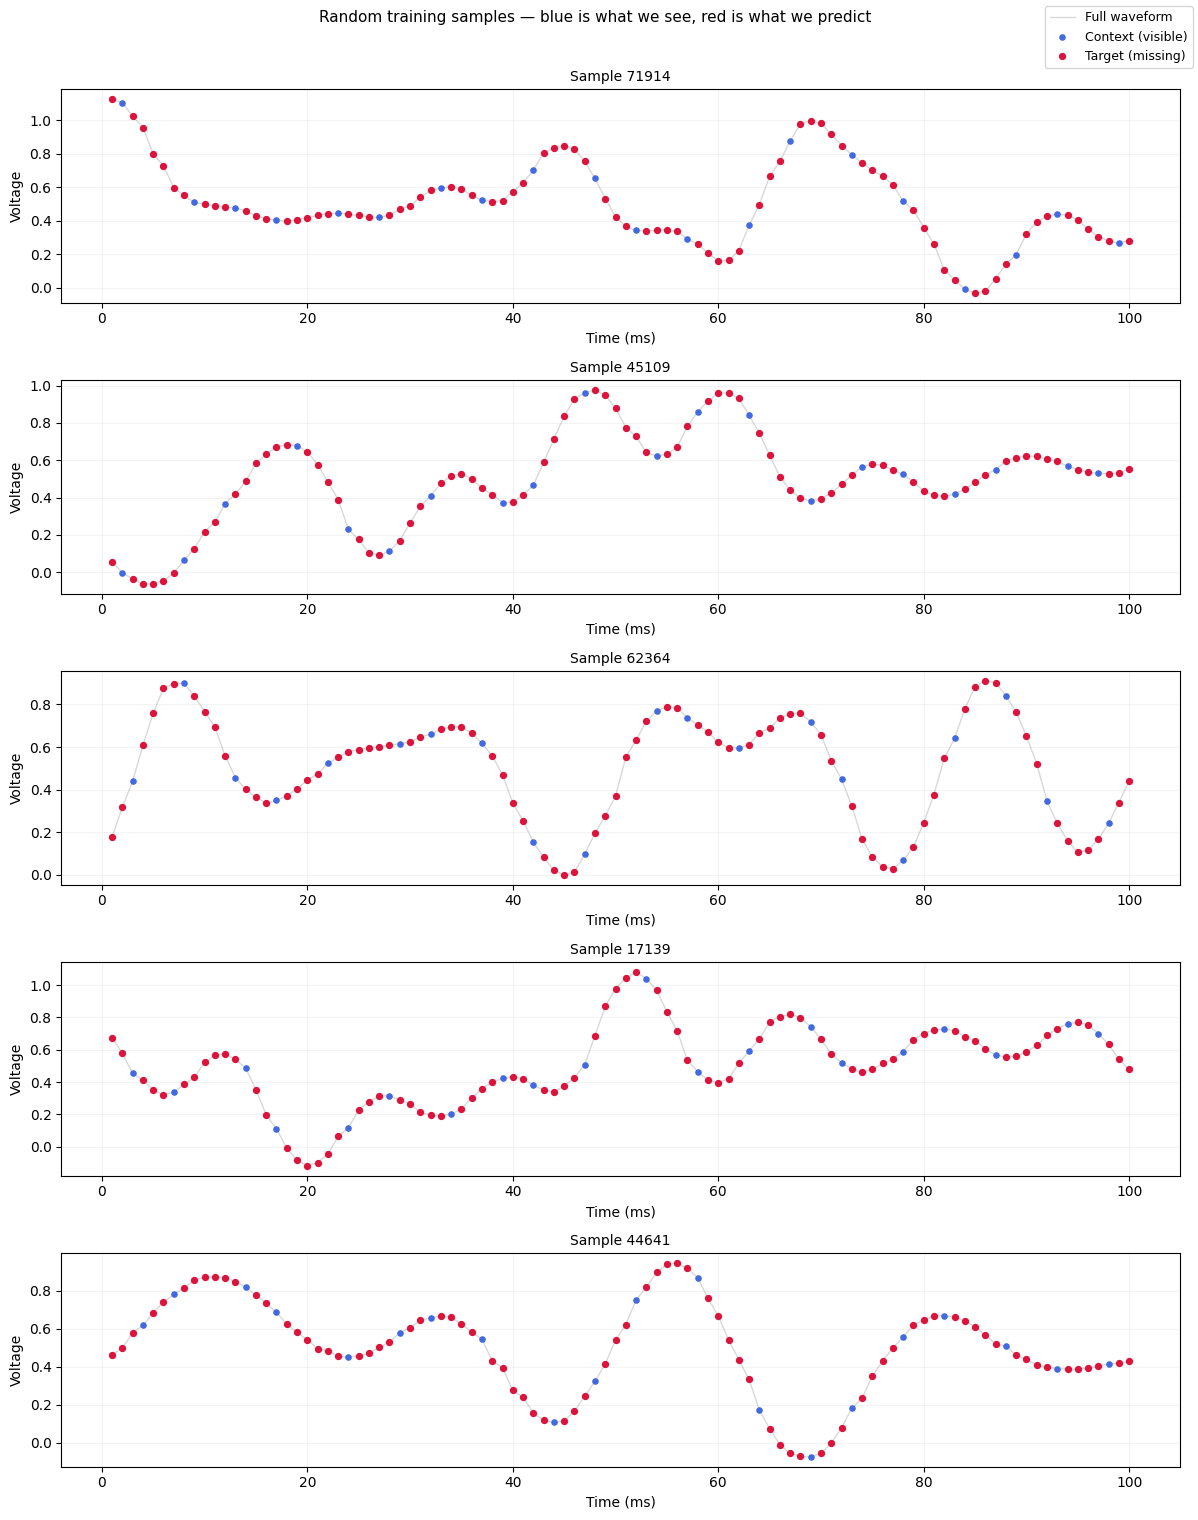

Building sample records: 100%|██████████| 80000/80000 [00:04<00:00, 17240.28it/s]



Split: 72,000 train / 8,000 val samples
Model params: 200,577


Baseline (context mean) val MSE: 0.062169
Resuming from checkpoint: best_anp.pt
Resumed at epoch 9, best val MSE = 0.006512


Epoch 009/12  |  Train MSE 0.010351  |  Val MSE 0.006320  |  LR 9.86e-04
  >> saved checkpoint (val MSE = 0.006320)


Epoch 010/12  |  Train MSE 0.010271  |  Val MSE 0.006328  |  LR 9.81e-04


Epoch 011/12  |  Train MSE 0.010120  |  Val MSE 0.006376  |  LR 9.76e-04


Epoch 012/12  |  Train MSE 0.009947  |  Val MSE 0.006050  |  LR 9.69e-04
  >> saved checkpoint (val MSE = 0.006050)


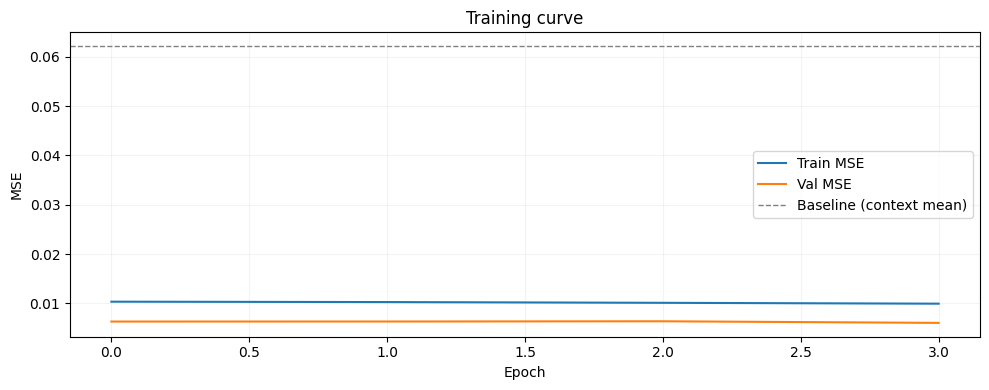


Loaded best checkpoint — epoch 12, val MSE = 0.006050


Confirmed val MSE on reload: 0.006050


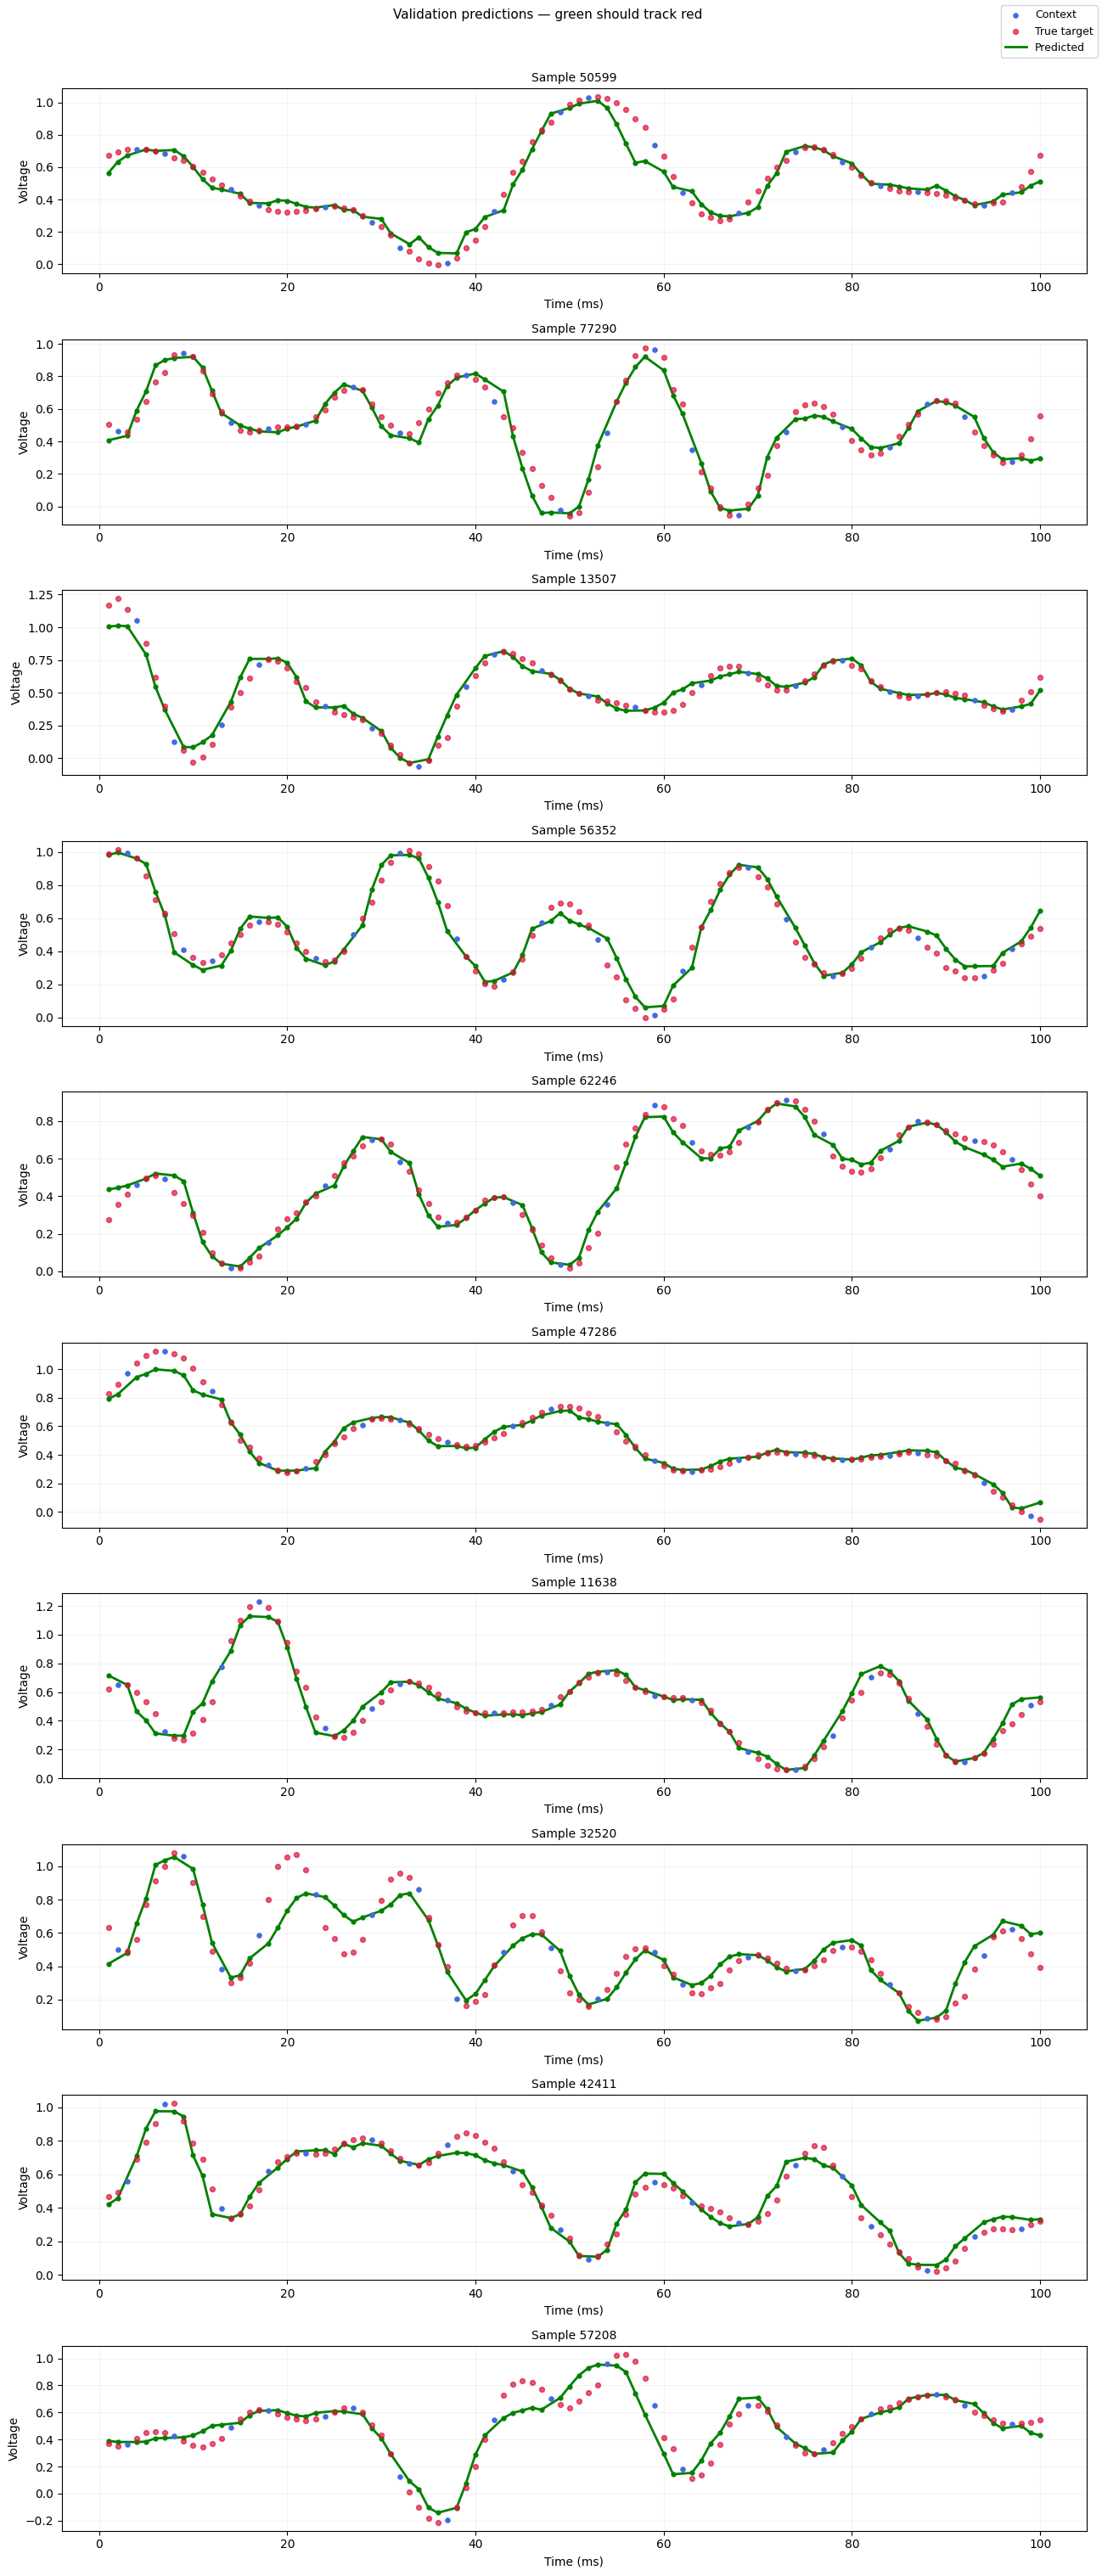


Test file found: test.csv


Inference: 100%|██████████| 1/1 [00:00<00:00, 90.66it/s]


Submission saved: /Users/aman/Downloads/Spectral Bridge/submission.csv
Rows: 14
   Sample_ID  Time_ms  Predicted_Value
0      20000      1.0         0.569903
1      20000      3.0         0.598202
2      20000      4.0         0.615793
3      20000      5.0         0.623479
4      20000      6.0         0.618151
5      20000      7.0         0.615715
6      20000      8.0         0.579356
7      20000     10.0         0.472231
8      20000     11.0         0.426519
9      20000     13.0         0.410709


In [34]:
def main(cfg: Config):
    set_seed(cfg.seed)
    device = get_device()
    print(f"Device: {device}")

    # ── 1. Load and explore the data ─────────────────────────────────────
    train_df = load_dataframe(cfg.train_csv, is_train=True)
    eda_report(train_df)
    plot_random_samples(train_df, n_samples=5, seed=cfg.seed)

    # ── 2. Build sample records and split train / val ────────────────────
    # Split by Sample_ID (not by rows!) to avoid leaking waveform info
    all_records = build_sample_records(train_df, cfg.time_norm_divisor)
    sample_ids  = [int(r["sample_id"]) for r in all_records]

    train_ids, val_ids = train_test_split(sample_ids, test_size=cfg.val_size,
                                          random_state=cfg.seed, shuffle=True)
    train_set = set(train_ids)
    val_set   = set(val_ids)

    train_records = [r for r in all_records if int(r["sample_id"]) in train_set]
    val_records   = [r for r in all_records if int(r["sample_id"]) in val_set]
    print(f"\nSplit: {len(train_records):,} train / {len(val_records):,} val samples")

    train_loader = DataLoader(
        SpectralBridgeDataset(train_records, train_mode=True, cfg=cfg),
        batch_size=cfg.batch_size, shuffle=True,
        num_workers=cfg.num_workers, pin_memory=(device.type == "cuda"),
        collate_fn=collate_train_val,
    )
    val_loader = DataLoader(
        SpectralBridgeDataset(val_records, train_mode=False, cfg=cfg),
        batch_size=cfg.batch_size, shuffle=False,
        num_workers=cfg.num_workers, pin_memory=(device.type == "cuda"),
        collate_fn=collate_train_val,
    )

    # ── 3. Build the model ───────────────────────────────────────────────
    model = AttentiveNeuralProcess(
        num_frequencies=cfg.num_frequencies, d_hidden=cfg.d_hidden,
        encoder_layers=cfg.encoder_layers,   decoder_layers=cfg.decoder_layers,
        attention_heads=cfg.attention_heads,  dropout=cfg.dropout,
    ).to(device)
    print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

    # Sanity check: how good is a brain-dead baseline?
    bl_mse = baseline_context_mean(val_loader, device)
    print(f"Baseline (context mean) val MSE: {bl_mse:.6f}")

    # ── 4. Train ─────────────────────────────────────────────────────────
    history = train_model(model, train_loader, val_loader, cfg, device)

    # Plot the learning curves
    plt.figure(figsize=(10, 4))
    plt.plot(history["train_mse"], label="Train MSE", lw=1.5)
    plt.plot(history["val_mse"],   label="Val MSE",   lw=1.5)
    plt.axhline(bl_mse, color="gray", ls="--", lw=1, label="Baseline (context mean)")
    plt.xlabel("Epoch");  plt.ylabel("MSE")
    plt.title("Training curve");  plt.legend();  plt.grid(alpha=0.15)
    plt.tight_layout();  plt.show()

    # ── 5. Reload best checkpoint and evaluate ───────────────────────────
    ckpt = torch.load(cfg.checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    print(f"\nLoaded best checkpoint — epoch {ckpt.get('epoch', '?')}, val MSE = {ckpt.get('best_val_mse', float('nan')):.6f}")

    final_mse = run_one_epoch(model, val_loader, None, device, train=False)
    print(f"Confirmed val MSE on reload: {final_mse:.6f}")

    plot_val_predictions(model, val_records, device, n=10, seed=cfg.seed + 1)

    # ── 6. Inference and submission ──────────────────────────────────────
    test_csv = find_test_csv(cfg.test_csv_candidates)

    if test_csv is not None:
        print(f"\nTest file found: {test_csv}")
        test_df = load_dataframe(test_csv, is_train=False)
        if "Value" not in test_df.columns:
            test_df["Value"] = np.nan
        infer_records = build_sample_records(test_df, cfg.time_norm_divisor)
    else:
        print("\nNo test CSV found — running sanity inference on training data.")
        infer_records = all_records

    sub = run_inference(model, infer_records, cfg.batch_size, cfg.num_workers, device)
    sub.to_csv(cfg.submission_path, index=False)
    print(f"\nSubmission saved: {cfg.submission_path.resolve()}")
    print(f"Rows: {len(sub):,}")
    print(sub.head(10))

main(CFG)


## Inference Only: Load Model and Predict
This cell loads the trained model and runs inference on the test data (or training data if no test set is found), saving predictions to `submission.csv`.

In [35]:
# Inference-only cell: skip training, just load model and predict

def inference_only(cfg):
    import torch
    device = get_device()
    print(f"Device: {device}")

    # Load data
    train_df = load_dataframe(cfg.train_csv, is_train=True)
    all_records = build_sample_records(train_df, cfg.time_norm_divisor)

    # Build model
    model = AttentiveNeuralProcess(
        num_frequencies=cfg.num_frequencies, d_hidden=cfg.d_hidden,
        encoder_layers=cfg.encoder_layers,   decoder_layers=cfg.decoder_layers,
        attention_heads=cfg.attention_heads,  dropout=cfg.dropout,
    ).to(device)

    # Load checkpoint
    ckpt = torch.load(cfg.checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    print(f"Loaded best checkpoint — epoch {ckpt.get('epoch', '?')}, val MSE = {ckpt.get('best_val_mse', float('nan')):.6f}")

    # Find test data
    test_csv = find_test_csv(cfg.test_csv_candidates)
    if test_csv is not None:
        print(f"Test file found: {test_csv}")
        test_df = load_dataframe(test_csv, is_train=False)
        if "Value" not in test_df.columns:
            test_df["Value"] = np.nan
        infer_records = build_sample_records(test_df, cfg.time_norm_divisor)
    else:
        print("No test CSV found — running inference on training data.")
        infer_records = all_records

    # Run inference
    sub = run_inference(model, infer_records, cfg.batch_size, cfg.num_workers, device)
    sub.to_csv(cfg.submission_path, index=False)
    print(f"Submission saved: {cfg.submission_path.resolve()}")
    print(f"Rows: {len(sub):,}")
    print(sub.head(10))

# Run inference only
inference_only(CFG)

Device: mps


Building sample records: 100%|██████████| 80000/80000 [00:04<00:00, 16827.11it/s]


Loaded best checkpoint — epoch 12, val MSE = 0.006050
Test file found: test.csv


Inference: 100%|██████████| 1/1 [00:00<00:00, 144.95it/s]

Submission saved: /Users/aman/Downloads/Spectral Bridge/submission.csv
Rows: 14
   Sample_ID  Time_ms  Predicted_Value
0      20000      1.0         0.569903
1      20000      3.0         0.598202
2      20000      4.0         0.615793
3      20000      5.0         0.623479
4      20000      6.0         0.618151
5      20000      7.0         0.615715
6      20000      8.0         0.579356
7      20000     10.0         0.472231
8      20000     11.0         0.426519
9      20000     13.0         0.410709


## Visualize Test Data and Predictions
This cell plots the original test.csv (showing context and missing points) and overlays the predicted values from submission.csv, so you can see where the model is filling in the gaps.

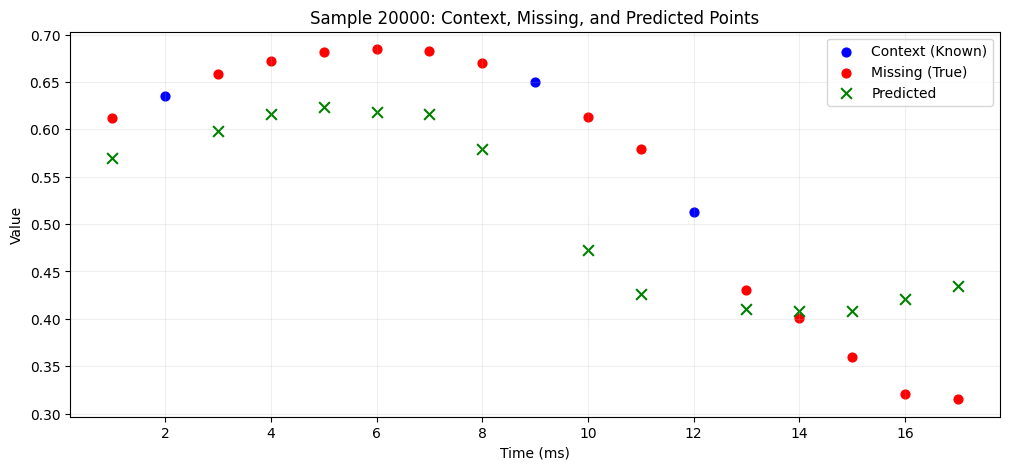

In [36]:
# Visualization: Show context, missing, and predicted points
import pandas as pd
import matplotlib.pyplot as plt

# Load test and submission data
# (Adjust paths if needed)
test_df = pd.read_csv('test.csv')
pred_df = pd.read_csv('submission.csv')

sample_id = test_df['Sample_ID'].iloc[0]  # Visualize the first sample (change as needed)
test_sample = test_df[test_df['Sample_ID'] == sample_id]
pred_sample = pred_df[pred_df['Sample_ID'] == sample_id]

plt.figure(figsize=(12, 5))
# Plot context points
plt.scatter(test_sample[test_sample['Is_Context'] == 1]['Time_ms'],
            test_sample[test_sample['Is_Context'] == 1]['Value'],
            color='blue', label='Context (Known)', s=40)
# Plot missing (target) points (ground truth)
plt.scatter(test_sample[test_sample['Is_Context'] == 0]['Time_ms'],
            test_sample[test_sample['Is_Context'] == 0]['Value'],
            color='red', label='Missing (True)', s=40)
# Plot predictions
plt.scatter(pred_sample['Time_ms'], pred_sample['Predicted_Value'],
            color='green', label='Predicted', marker='x', s=60)

plt.title(f'Sample {sample_id}: Context, Missing, and Predicted Points')
plt.xlabel('Time (ms)')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

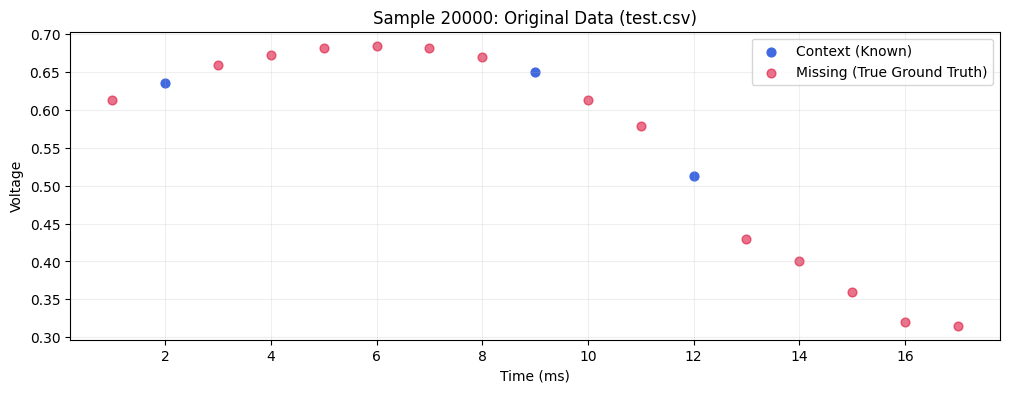

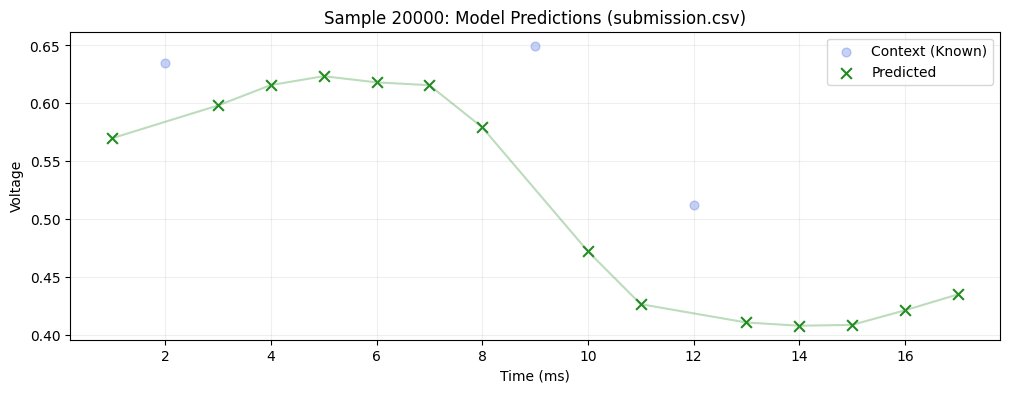

In [39]:
# Load the data to visualize performance on test samples
test_df = pd.read_csv('test.csv')
pred_df = pd.read_csv('submission.csv')

unique_samples = test_df['Sample_ID'].unique()

# Visualize the first two available samples with separate graphs
for sid in unique_samples[:2]:
    test_sample = test_df[test_df['Sample_ID'] == sid].sort_values('Time_ms')
    pred_sample = pred_df[pred_df['Sample_ID'] == sid].sort_values('Time_ms')

    # Plot 1: Original test.csv Data
    plt.figure(figsize=(12, 4))
    ctx = test_sample[test_sample['Is_Context'] == 1]
    tgt = test_sample[test_sample['Is_Context'] == 0]
    plt.scatter(ctx['Time_ms'], ctx['Value'], color='royalblue', label='Context (Known)', s=40)
    plt.scatter(tgt['Time_ms'], tgt['Value'], color='crimson', label='Missing (True Ground Truth)', s=40, alpha=0.6)
    plt.title(f'Sample {sid}: Original Data (test.csv)')
    plt.xlabel('Time (ms)')
    plt.ylabel('Voltage')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    # Plot 2: submission.csv Predictions
    plt.figure(figsize=(12, 4))
    plt.scatter(ctx['Time_ms'], ctx['Value'], color='royalblue', label='Context (Known)', s=40, alpha=0.3)
    plt.scatter(pred_sample['Time_ms'], pred_sample['Predicted_Value'], color='forestgreen', label='Predicted', marker='x', s=60)
    plt.plot(pred_sample['Time_ms'], pred_sample['Predicted_Value'], color='forestgreen', alpha=0.3)
    plt.title(f'Sample {sid}: Model Predictions (submission.csv)')
    plt.xlabel('Time (ms)')
    plt.ylabel('Voltage')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()